# Myerson's Lemma Truthfulness Analysis

This notebook demonstrates that our diffusion auction mechanism is incentive compatible
using Myerson's lemma. Since the allocation rule is monotone (higher bid → higher CLIP alignment),
Myerson's lemma gives a unique truthful payment rule:

$$p_i(b_i) = b_i \cdot x_i(b_i) - \int_0^{b_i} x_i(z) \, dz$$

We compute this numerically and show that relative regret from truthful bidding is zero (or near-zero).

In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import interpolate
from collections import defaultdict

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_DIR = '../results/truthfulness'
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Load Alignment Data

In [2]:
def load_alignment_data(alignment_dir, prompts_path):
    """Load all alignment JSONs from a directory.
    
    Returns a DataFrame (possibly empty) with columns:
        prompt_idx, b1, b2, sample_idx, base_alignment, 
        agent1_alignment, agent2_alignment, total_welfare, weighted_alignment
    """
    if not os.path.exists(alignment_dir):
        print(f'Alignment dir not found: {alignment_dir}')
        return pd.DataFrame()
    
    with open(prompts_path) as f:
        prompts = json.load(f)
    
    records = []
    for prompt_idx in range(len(prompts)):
        prompt_dir = os.path.join(alignment_dir, f'prompt_{prompt_idx:03d}')
        if not os.path.isdir(prompt_dir):
            print(f'  Skipping prompt {prompt_idx} (not found)')
            continue
        
        json_files = glob.glob(os.path.join(prompt_dir, 'alignment_*.json'))
        if not json_files:
            print(f'  Skipping prompt {prompt_idx} (no alignment files)')
            continue
        
        for json_file in json_files:
            with open(json_file) as f:
                data = json.load(f)
            
            meta = data['metadata']
            bids = meta['bids']
            scores = data['alignment_scores']
            welfare = data['welfare_metrics']
            
            records.append({
                'prompt_idx': meta['prompt_index'],
                'b1': bids[0],
                'b2': bids[1],
                'sample_idx': meta['sample_index'],
                'base_alignment': scores['base_alignment'],
                'agent1_alignment': scores['agent1_alignment'],
                'agent2_alignment': scores['agent2_alignment'],
                'total_welfare': welfare['total_welfare'],
                'weighted_alignment': welfare['weighted_alignment'],
                'base_prompt': prompts[meta['prompt_index']]['base_prompt'],
                'agent1_prompt': prompts[meta['prompt_index']]['agent1_prompt'],
                'agent2_prompt': prompts[meta['prompt_index']]['agent2_prompt'],
            })
    
    df = pd.DataFrame(records)
    if len(df) > 0:
        print(f'Loaded {len(df)} alignment records from {alignment_dir}')
        print(f'  Prompts: {sorted(df.prompt_idx.unique())}, Bid combos: {len(df.groupby(["b1", "b2"]))}, Samples/combo: {df.groupby(["prompt_idx", "b1", "b2"]).size().mode().values[0]}')
    else:
        print(f'No alignment data found in {alignment_dir}')
    return df

In [3]:
# Load regular and competitive data (handles missing/partial gracefully)
df_regular = load_alignment_data(
    '../alignment/truthfulness_clip_regular',
    '../prompts/truthfulness_regular.json'
)

df_competitive = load_alignment_data(
    '../alignment/truthfulness_clip_competitive',
    '../prompts/truthfulness_competitive.json'
)

HAS_REGULAR = len(df_regular) > 0
HAS_COMPETITIVE = len(df_competitive) > 0
print(f'\nData available — Regular: {HAS_REGULAR}, Competitive: {HAS_COMPETITIVE}')

Loaded 3510 alignment records from ../alignment/truthfulness_clip_regular
  Prompts: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)], Bid combos: 117, Samples/combo: 5


Loaded 1755 alignment records from ../alignment/truthfulness_clip_competitive
  Prompts: [np.int64(0), np.int64(1), np.int64(2)], Bid combos: 117, Samples/combo: 5

Data available — Regular: True, Competitive: True


## 2. Select Welfare-Optimal Samples

For each (prompt, bid_combo), pick the sample with highest `total_welfare` out of k=5.

In [4]:
def select_welfare_optimal(df):
    """For each (prompt_idx, b1, b2), select the sample with highest total_welfare."""
    if len(df) == 0:
        return df
    idx = df.groupby(['prompt_idx', 'b1', 'b2'])['total_welfare'].idxmax()
    df_opt = df.loc[idx].reset_index(drop=True)
    print(f'Selected {len(df_opt)} welfare-optimal samples from {len(df)} total')
    return df_opt

df_reg_opt = select_welfare_optimal(df_regular) if HAS_REGULAR else pd.DataFrame()
df_comp_opt = select_welfare_optimal(df_competitive) if HAS_COMPETITIVE else pd.DataFrame()

Selected 702 welfare-optimal samples from 3510 total
Selected 351 welfare-optimal samples from 1755 total


## 3. Build Allocation Curves

For each (prompt, agent, fixed_opponent_value), extract CLIP alignment at discrete bids
and linearly interpolate between them.

The allocation curve $x_i(b_i | b_{-i})$ maps agent $i$'s bid to their CLIP alignment.

In [5]:
# Discrete bid values used in Phase A (0.1 increments)
DISCRETE_BIDS = np.round(np.arange(0.0, 1.05, 0.1), 2)
# Fixed opponent values tested
FIXED_VALUES = [0.3, 0.5, 0.7]
# Interpolated bid values (Phase B midpoints, used as "true values")
INTERP_BIDS = np.round(np.arange(0.05, 1.0, 0.1), 2)
# All bid values combined
ALL_BIDS = np.sort(np.unique(np.concatenate([DISCRETE_BIDS, INTERP_BIDS])))

print(f'Discrete bids: {DISCRETE_BIDS}')
print(f'Interpolated bids: {INTERP_BIDS}')
print(f'Fixed opponent values: {FIXED_VALUES}')
print(f'All bids ({len(ALL_BIDS)}): {ALL_BIDS}')

Discrete bids: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Interpolated bids: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Fixed opponent values: [0.3, 0.5, 0.7]
All bids (21): [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]


In [6]:
def build_allocation_curves(df_opt, agent_col, vary_col, fixed_col):
    """Build allocation curves for one agent.
    
    Args:
        df_opt: Welfare-optimal DataFrame
        agent_col: 'agent1_alignment' or 'agent2_alignment'
        vary_col: 'b1' or 'b2' (the bid that varies)
        fixed_col: 'b2' or 'b1' (the fixed opponent bid)
    
    Returns:
        dict: {(prompt_idx, fixed_val): {'bids': array, 'allocations': array, 'interp_fn': callable}}
    """
    curves = {}
    if len(df_opt) == 0:
        return curves
    
    for prompt_idx in df_opt['prompt_idx'].unique():
        for fixed_val in FIXED_VALUES:
            # Get data for this prompt and fixed opponent value
            mask = (df_opt['prompt_idx'] == prompt_idx) & (np.isclose(df_opt[fixed_col], fixed_val))
            subset = df_opt[mask].sort_values(vary_col)
            
            if len(subset) < 2:
                continue
            
            bids = subset[vary_col].values
            allocations = subset[agent_col].values
            
            # Linear interpolation of discrete allocation values
            interp_fn = interpolate.interp1d(
                bids, allocations, kind='linear', 
                fill_value='extrapolate', bounds_error=False
            )
            
            curves[(prompt_idx, fixed_val)] = {
                'bids': bids,
                'allocations': allocations,
                'interp_fn': interp_fn
            }
    
    return curves

# Build curves for available data
if HAS_REGULAR:
    curves_a1_reg = build_allocation_curves(df_reg_opt, 'agent1_alignment', 'b1', 'b2')
    curves_a2_reg = build_allocation_curves(df_reg_opt, 'agent2_alignment', 'b2', 'b1')
    print(f'Regular: {len(curves_a1_reg)} A1 curves, {len(curves_a2_reg)} A2 curves')
else:
    curves_a1_reg, curves_a2_reg = {}, {}
    print('Regular: no data')

if HAS_COMPETITIVE:
    curves_a1_comp = build_allocation_curves(df_comp_opt, 'agent1_alignment', 'b1', 'b2')
    curves_a2_comp = build_allocation_curves(df_comp_opt, 'agent2_alignment', 'b2', 'b1')
    print(f'Competitive: {len(curves_a1_comp)} A1 curves, {len(curves_a2_comp)} A2 curves')
else:
    curves_a1_comp, curves_a2_comp = {}, {}
    print('Competitive: no data')

Regular: 18 A1 curves, 18 A2 curves
Competitive: 9 A1 curves, 9 A2 curves


## 4. Compute Myerson Payments

For each bid $b_i$, the Myerson payment is:

$$p_i(b_i) = b_i \cdot x_i(b_i) - \int_0^{b_i} x_i(z) \, dz$$

We compute the integral using the trapezoidal rule on the linear-interpolated allocation curve.

In [7]:
def compute_myerson_payment(interp_fn, bid, n_quadrature=1000):
    """Compute Myerson payment at a given bid.
    
    p(b) = b * x(b) - integral_0^b x(z) dz
    """
    x_at_bid = float(interp_fn(bid))
    
    # Trapezoidal integration
    z_vals = np.linspace(0, bid, n_quadrature)
    x_vals = interp_fn(z_vals)
    integral = np.trapz(x_vals, z_vals)
    
    payment = bid * x_at_bid - integral
    return max(payment, 0.0)  # Payment should be non-negative


def compute_utility(true_value, bid, interp_fn):
    """Compute agent utility: u(v, b) = v * x(b) - p(b)."""
    x_at_bid = float(interp_fn(bid))
    payment = compute_myerson_payment(interp_fn, bid)
    return true_value * x_at_bid - payment


def compute_regret_curve(interp_fn, true_values=None, bid_grid=None):
    """Compute relative regret for each true value.
    
    For each true value v:
    - Truthful utility: u(v, b=v)
    - Optimal utility: max_b u(v, b)
    - Relative regret: (optimal - truthful) / |truthful|
    
    Returns DataFrame with columns: true_value, truthful_utility, optimal_utility,
                                     optimal_bid, relative_regret
    """
    if true_values is None:
        true_values = INTERP_BIDS
    if bid_grid is None:
        bid_grid = ALL_BIDS
    
    results = []
    for v in true_values:
        u_truthful = compute_utility(v, v, interp_fn)
        
        # Find optimal bid
        utilities = [compute_utility(v, b, interp_fn) for b in bid_grid]
        best_idx = np.argmax(utilities)
        u_optimal = utilities[best_idx]
        b_optimal = bid_grid[best_idx]
        
        # Relative regret
        if abs(u_truthful) > 1e-10:
            rel_regret = (u_optimal - u_truthful) / abs(u_truthful)
        else:
            rel_regret = 0.0 if abs(u_optimal - u_truthful) < 1e-10 else np.inf
        
        results.append({
            'true_value': v,
            'truthful_utility': u_truthful,
            'optimal_utility': u_optimal,
            'optimal_bid': b_optimal,
            'relative_regret': rel_regret,
        })
    
    return pd.DataFrame(results)

# Test on one curve (if available)
if curves_a1_reg:
    test_key = list(curves_a1_reg.keys())[0]
    test_curve = curves_a1_reg[test_key]
    test_regret = compute_regret_curve(test_curve['interp_fn'])
    print(f'Test curve key: {test_key}')
    print(test_regret[['true_value', 'truthful_utility', 'optimal_bid', 'relative_regret']].to_string(index=False))
else:
    print('No regular curves available yet for testing')

Test curve key: (np.int64(0), 0.3)
 true_value  truthful_utility  optimal_bid  relative_regret
       0.05          0.008350         0.65         0.111111
       0.15          0.025970         0.65         0.071680
       0.25          0.044354         0.65         0.045824
       0.35          0.063373         0.95         0.044305
       0.45          0.083148         0.95         0.037879
       0.55          0.103143         0.95         0.031719
       0.65          0.120605         0.95         0.049141
       0.75          0.143329         0.35         0.028106
       0.85          0.166058         0.35         0.013820
       0.95          0.186884         0.80         0.018551


/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


## 5. Per-Prompt Analysis

For each prompt, plot allocation curves, payment curves, utility curves, and regret heatmaps.

In [8]:
def plot_allocation_curves(curves, agent_name, dataset_name, prompts):
    """Plot allocation curves x_i(b_i) for each prompt and fixed opponent value."""
    prompt_indices = sorted(set(k[0] for k in curves.keys()))
    
    fig, axes = plt.subplots(1, len(prompt_indices), figsize=(5*len(prompt_indices), 4), squeeze=False)
    colors = {0.3: 'tab:blue', 0.5: 'tab:orange', 0.7: 'tab:red'}
    
    for col, pidx in enumerate(prompt_indices):
        ax = axes[0, col]
        for fv in FIXED_VALUES:
            key = (pidx, fv)
            if key not in curves:
                continue
            c = curves[key]
            # Plot raw data points
            ax.scatter(c['bids'], c['allocations'], color=colors[fv], s=20, zorder=5)
            # Plot interpolated line
            fine_bids = np.linspace(0, 1, 200)
            ax.plot(fine_bids, c['interp_fn'](fine_bids), color=colors[fv], 
                    label=f'Opp={fv}', linewidth=1.5)
        
        ax.set_xlabel(f'{agent_name} Bid')
        ax.set_ylabel('CLIP Alignment')
        ax.set_title(f'P{pidx}: {prompts[pidx]["base_prompt"][:30]}...', fontsize=10)
        ax.legend(fontsize=8)
        ax.set_xlim(-0.02, 1.02)
    
    fig.suptitle(f'Allocation Curves — {agent_name} ({dataset_name})', fontsize=14)
    plt.tight_layout()
    return fig

In [9]:
def plot_payment_curves(curves, agent_name, dataset_name, prompts):
    """Plot Myerson payment curves p_i(b_i)."""
    prompt_indices = sorted(set(k[0] for k in curves.keys()))
    
    fig, axes = plt.subplots(1, len(prompt_indices), figsize=(5*len(prompt_indices), 4), squeeze=False)
    colors = {0.3: 'tab:blue', 0.5: 'tab:orange', 0.7: 'tab:red'}
    
    for col, pidx in enumerate(prompt_indices):
        ax = axes[0, col]
        for fv in FIXED_VALUES:
            key = (pidx, fv)
            if key not in curves:
                continue
            interp_fn = curves[key]['interp_fn']
            fine_bids = np.linspace(0.01, 1.0, 200)
            payments = [compute_myerson_payment(interp_fn, b) for b in fine_bids]
            ax.plot(fine_bids, payments, color=colors[fv], label=f'Opp={fv}', linewidth=1.5)
        
        ax.set_xlabel(f'{agent_name} Bid')
        ax.set_ylabel('Myerson Payment')
        ax.set_title(f'P{pidx}: {prompts[pidx]["base_prompt"][:30]}...', fontsize=10)
        ax.legend(fontsize=8)
    
    fig.suptitle(f'Payment Curves — {agent_name} ({dataset_name})', fontsize=14)
    plt.tight_layout()
    return fig

In [10]:
def plot_utility_curves(curves, agent_name, dataset_name, prompts):
    """Plot utility curves u_i(b_i) for different true values, showing max at truthful bid."""
    prompt_indices = sorted(set(k[0] for k in curves.keys()))
    true_values_to_plot = [0.15, 0.35, 0.55, 0.75, 0.95]
    
    # One row per fixed opponent value
    fig, axes = plt.subplots(len(FIXED_VALUES), len(prompt_indices), 
                             figsize=(5*len(prompt_indices), 4*len(FIXED_VALUES)), squeeze=False)
    cmap = cm.viridis
    
    for row, fv in enumerate(FIXED_VALUES):
        for col, pidx in enumerate(prompt_indices):
            ax = axes[row, col]
            key = (pidx, fv)
            if key not in curves:
                ax.set_visible(False)
                continue
            
            interp_fn = curves[key]['interp_fn']
            bid_grid = np.linspace(0.01, 1.0, 200)
            
            for i, v in enumerate(true_values_to_plot):
                color = cmap(i / (len(true_values_to_plot) - 1))
                utilities = [compute_utility(v, b, interp_fn) for b in bid_grid]
                ax.plot(bid_grid, utilities, color=color, label=f'v={v}', linewidth=1.2)
                # Mark truthful bid
                u_truthful = compute_utility(v, v, interp_fn)
                ax.axvline(v, color=color, linestyle=':', alpha=0.3, linewidth=0.8)
                ax.plot(v, u_truthful, 'o', color=color, markersize=5)
            
            ax.set_xlabel(f'{agent_name} Bid')
            ax.set_ylabel('Utility')
            if row == 0:
                ax.set_title(f'P{pidx}: {prompts[pidx]["base_prompt"][:25]}...', fontsize=9)
            if col == 0:
                ax.set_ylabel(f'Opp={fv}\nUtility')
            ax.legend(fontsize=7, ncol=2)
    
    fig.suptitle(f'Utility Curves — {agent_name} ({dataset_name})', fontsize=14)
    plt.tight_layout()
    return fig

In [11]:
def compute_regret_heatmap(curves):
    """Compute regret for all (prompt, fixed_val, true_value) combinations.
    
    Returns DataFrame with columns: prompt_idx, fixed_val, true_value, relative_regret, ...
    """
    if not curves:
        return pd.DataFrame()
    all_regrets = []
    for (pidx, fv), curve_data in curves.items():
        regret_df = compute_regret_curve(curve_data['interp_fn'])
        regret_df['prompt_idx'] = pidx
        regret_df['fixed_val'] = fv
        all_regrets.append(regret_df)
    
    return pd.concat(all_regrets, ignore_index=True)

# Compute regrets for available data
regret_a1_reg = compute_regret_heatmap(curves_a1_reg)
regret_a2_reg = compute_regret_heatmap(curves_a2_reg)
regret_a1_comp = compute_regret_heatmap(curves_a1_comp)
regret_a2_comp = compute_regret_heatmap(curves_a2_comp)

if len(regret_a1_reg) > 0:
    print('Regular Agent 1 — Mean relative regret:', regret_a1_reg['relative_regret'].mean())
    print('Regular Agent 2 — Mean relative regret:', regret_a2_reg['relative_regret'].mean())
if len(regret_a1_comp) > 0:
    print('Competitive Agent 1 — Mean relative regret:', regret_a1_comp['relative_regret'].mean())
    print('Competitive Agent 2 — Mean relative regret:', regret_a2_comp['relative_regret'].mean())

/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration funct

/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration funct

...

/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration funct

/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)
/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


Regular Agent 1 — Mean relative regret: 0.10314205041238952
Regular Agent 2 — Mean relative regret: 0.11710622085310492
Competitive Agent 1 — Mean relative regret: 0.06273064139731975
Competitive Agent 2 — Mean relative regret: 0.0737905902290615


In [12]:
def plot_regret_heatmap(regret_df, agent_name, dataset_name):
    """Plot regret heatmap: true_value vs fixed_opponent_value, averaged across prompts."""
    # Average across prompts
    mean_regret = regret_df.groupby(['fixed_val', 'true_value'])['relative_regret'].mean().reset_index()
    pivot = mean_regret.pivot(index='fixed_val', columns='true_value', values='relative_regret')
    
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, 
                   vmax=max(0.01, pivot.values.max()))
    
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{v:.1f}' for v in pivot.index])
    ax.set_xlabel('Agent True Value')
    ax.set_ylabel('Opponent Fixed Bid')
    ax.set_title(f'Mean Relative Regret — {agent_name} ({dataset_name})')
    
    # Add text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.4f}', ha='center', va='center', fontsize=8,
                   color='white' if val > pivot.values.max()/2 else 'black')
    
    plt.colorbar(im, ax=ax, label='Relative Regret')
    plt.tight_layout()
    return fig

## 6. Generate All Plots — Regular

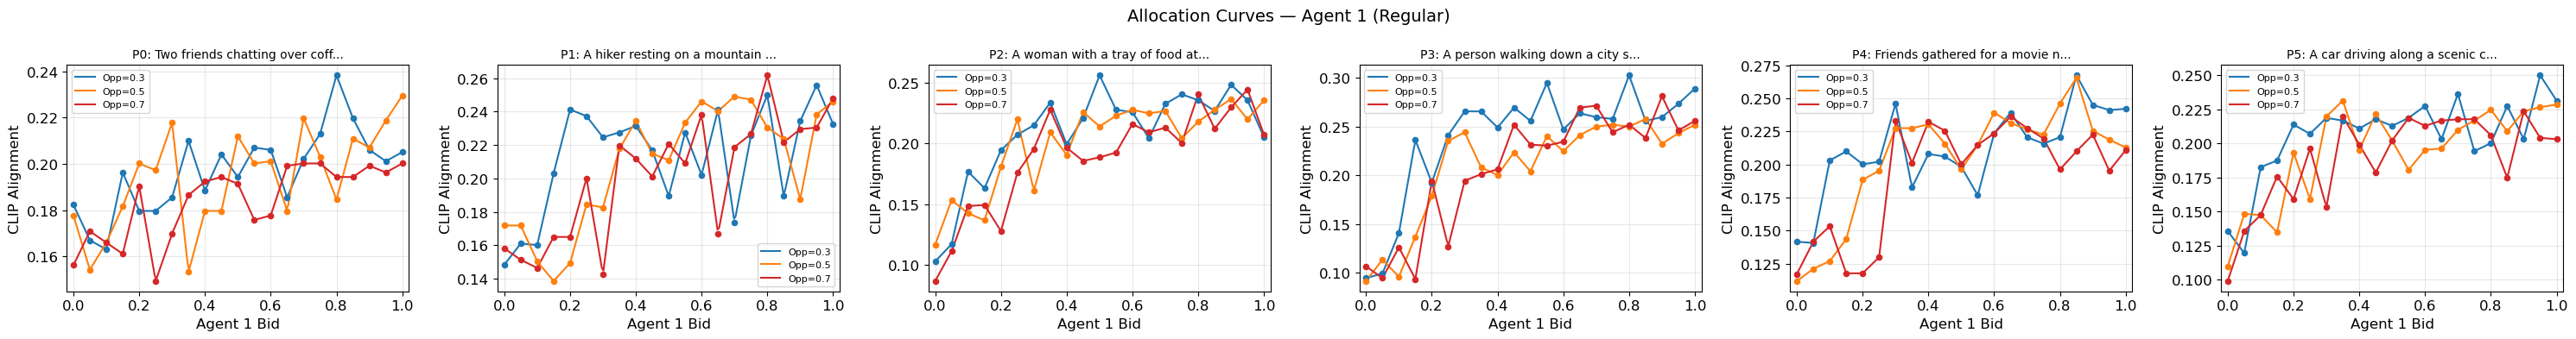

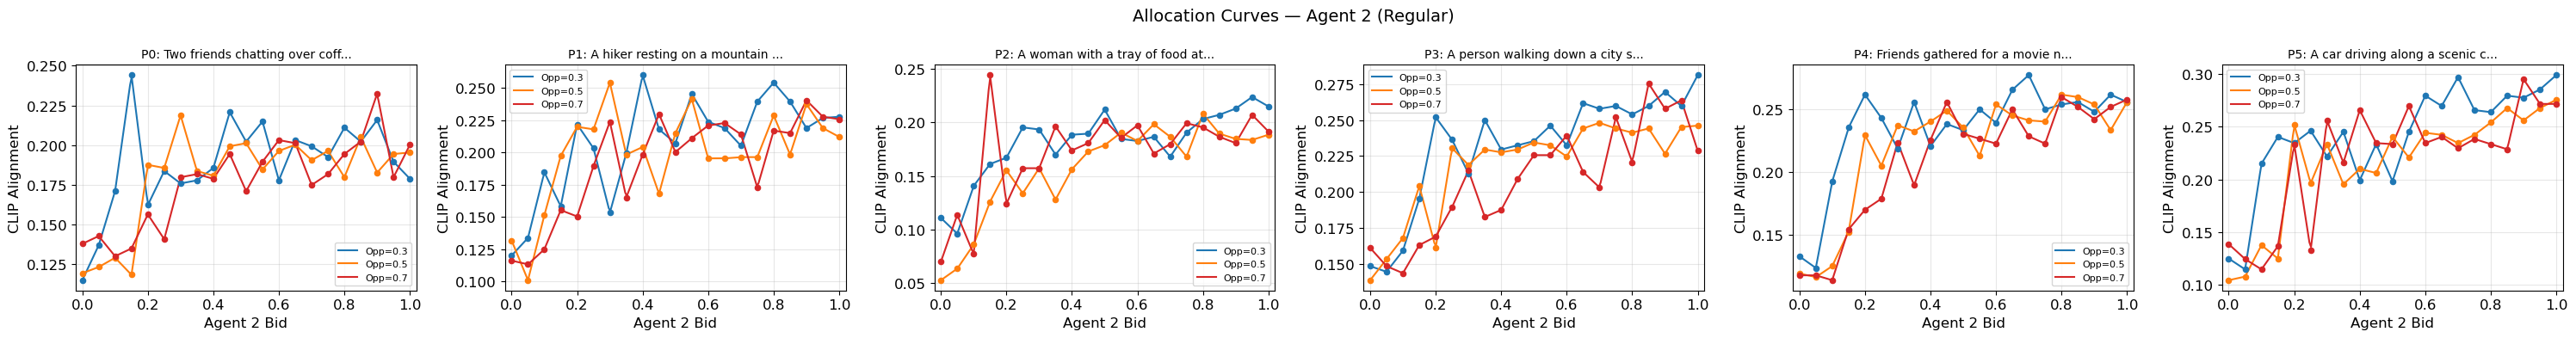

In [13]:
if HAS_REGULAR and curves_a1_reg:
    with open('../prompts/truthfulness_regular.json') as f:
        prompts_regular = json.load(f)

    fig = plot_allocation_curves(curves_a1_reg, 'Agent 1', 'Regular', prompts_regular)
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_curves_a1_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()

    fig = plot_allocation_curves(curves_a2_reg, 'Agent 2', 'Regular', prompts_regular)
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_curves_a2_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping regular allocation plots (no data)')

/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


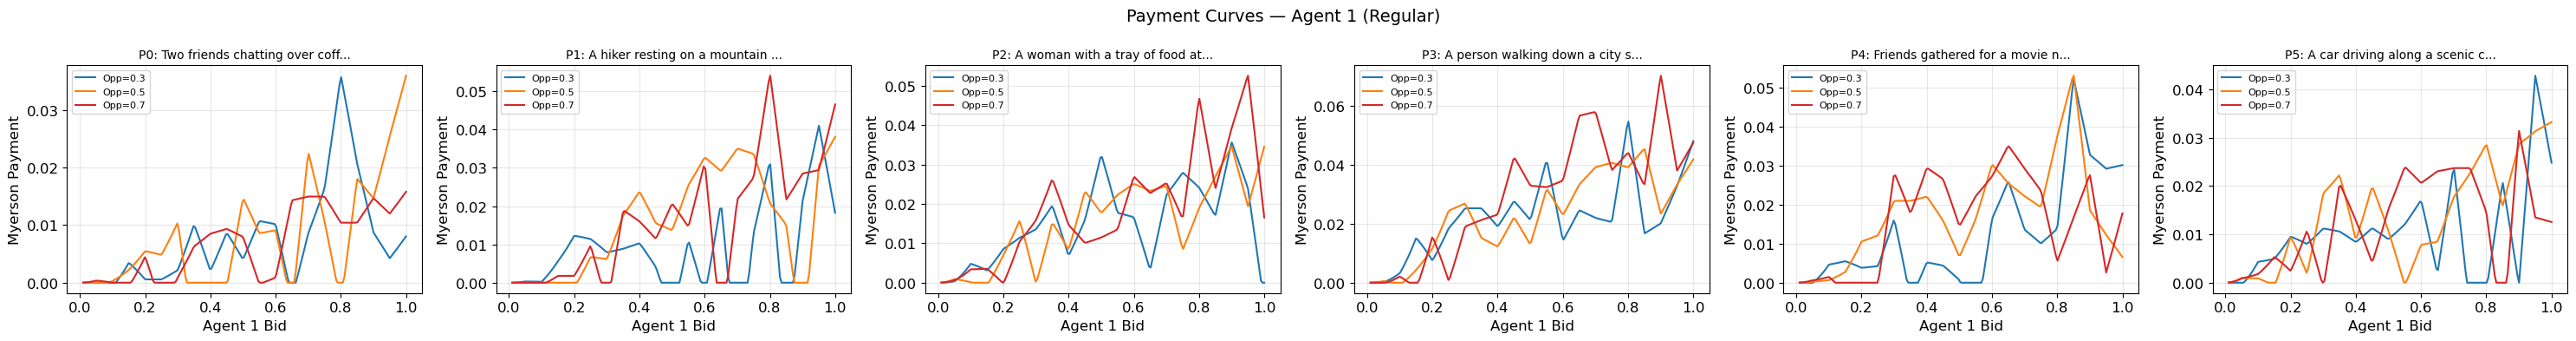

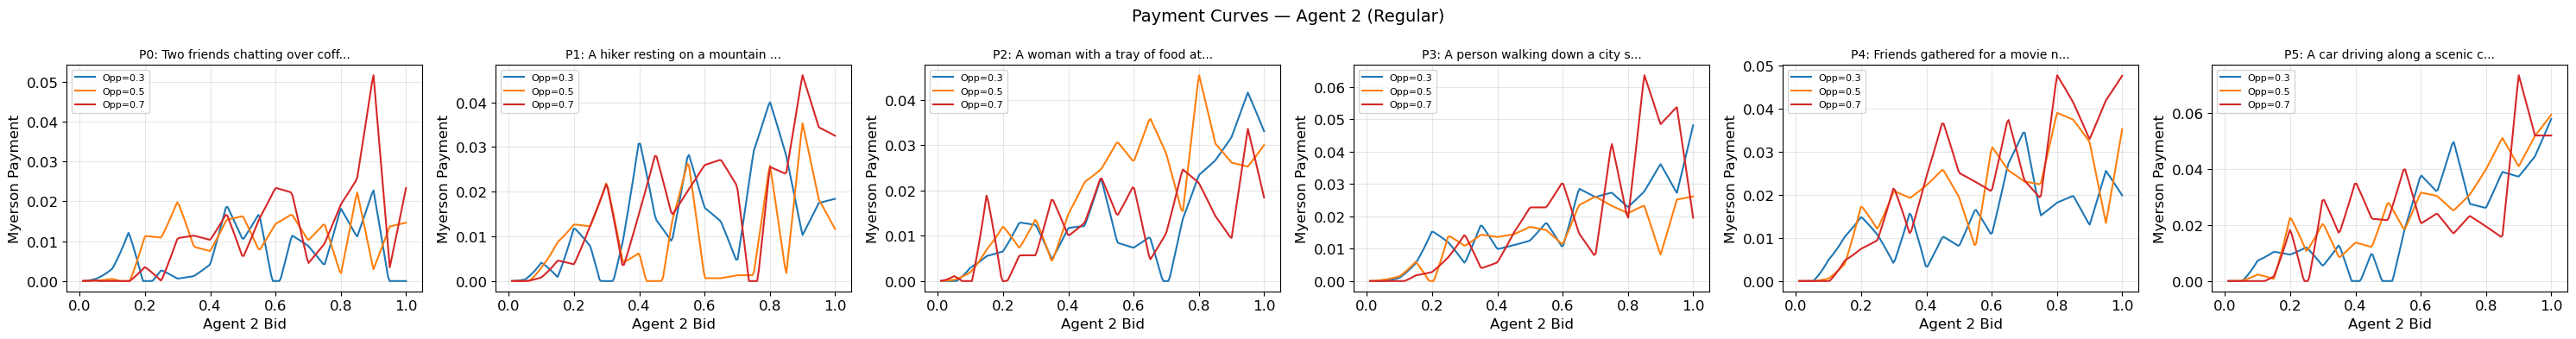

In [14]:
if HAS_REGULAR and curves_a1_reg:
    fig = plot_payment_curves(curves_a1_reg, 'Agent 1', 'Regular', prompts_regular)
    fig.savefig(os.path.join(RESULTS_DIR, 'payment_curves_a1_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()

    fig = plot_payment_curves(curves_a2_reg, 'Agent 2', 'Regular', prompts_regular)
    fig.savefig(os.path.join(RESULTS_DIR, 'payment_curves_a2_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping regular payment plots (no data)')

/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


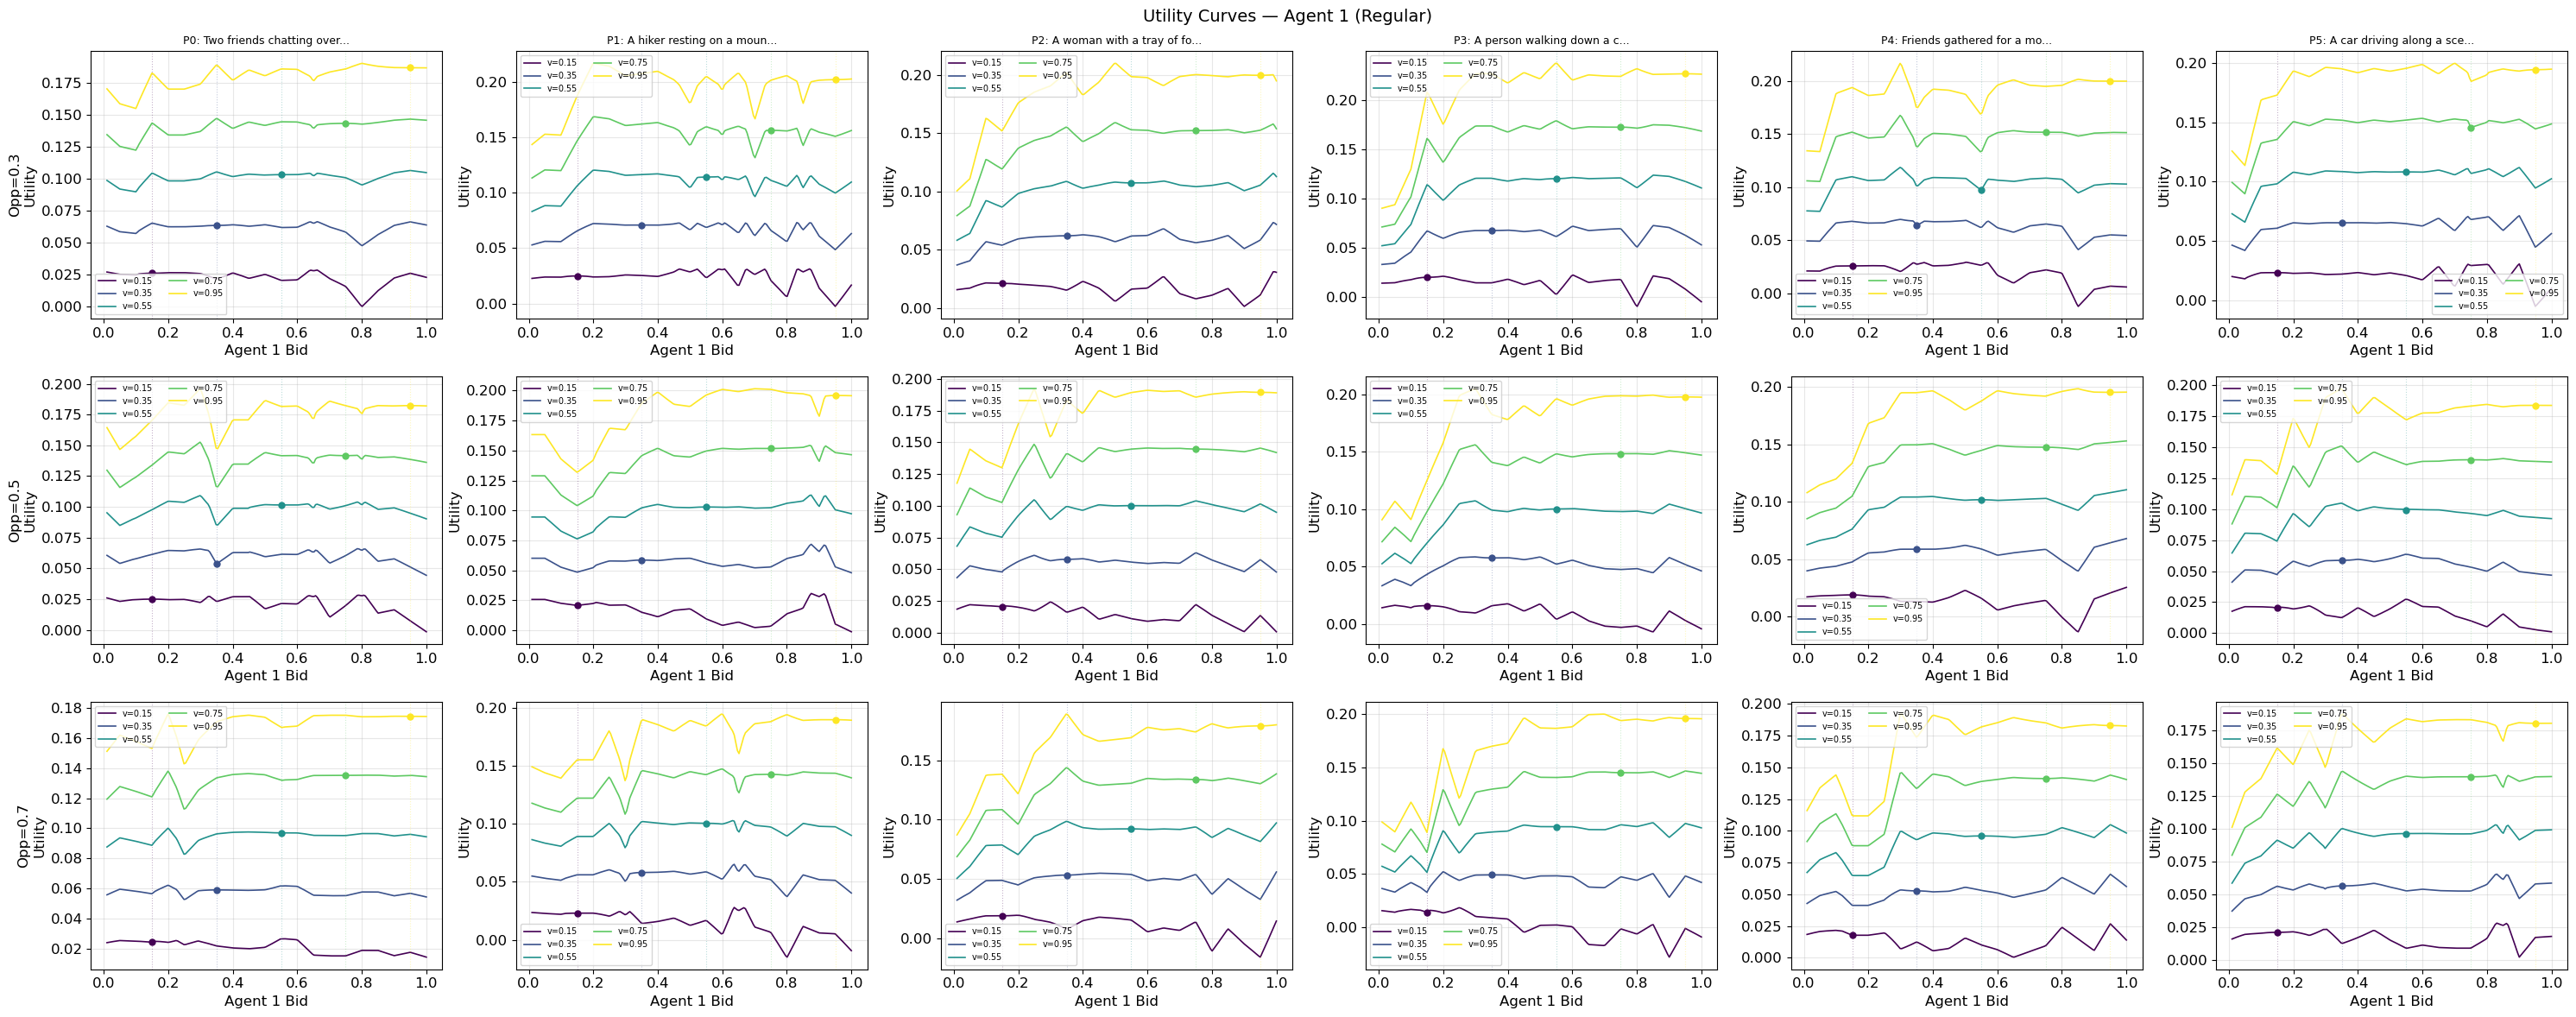

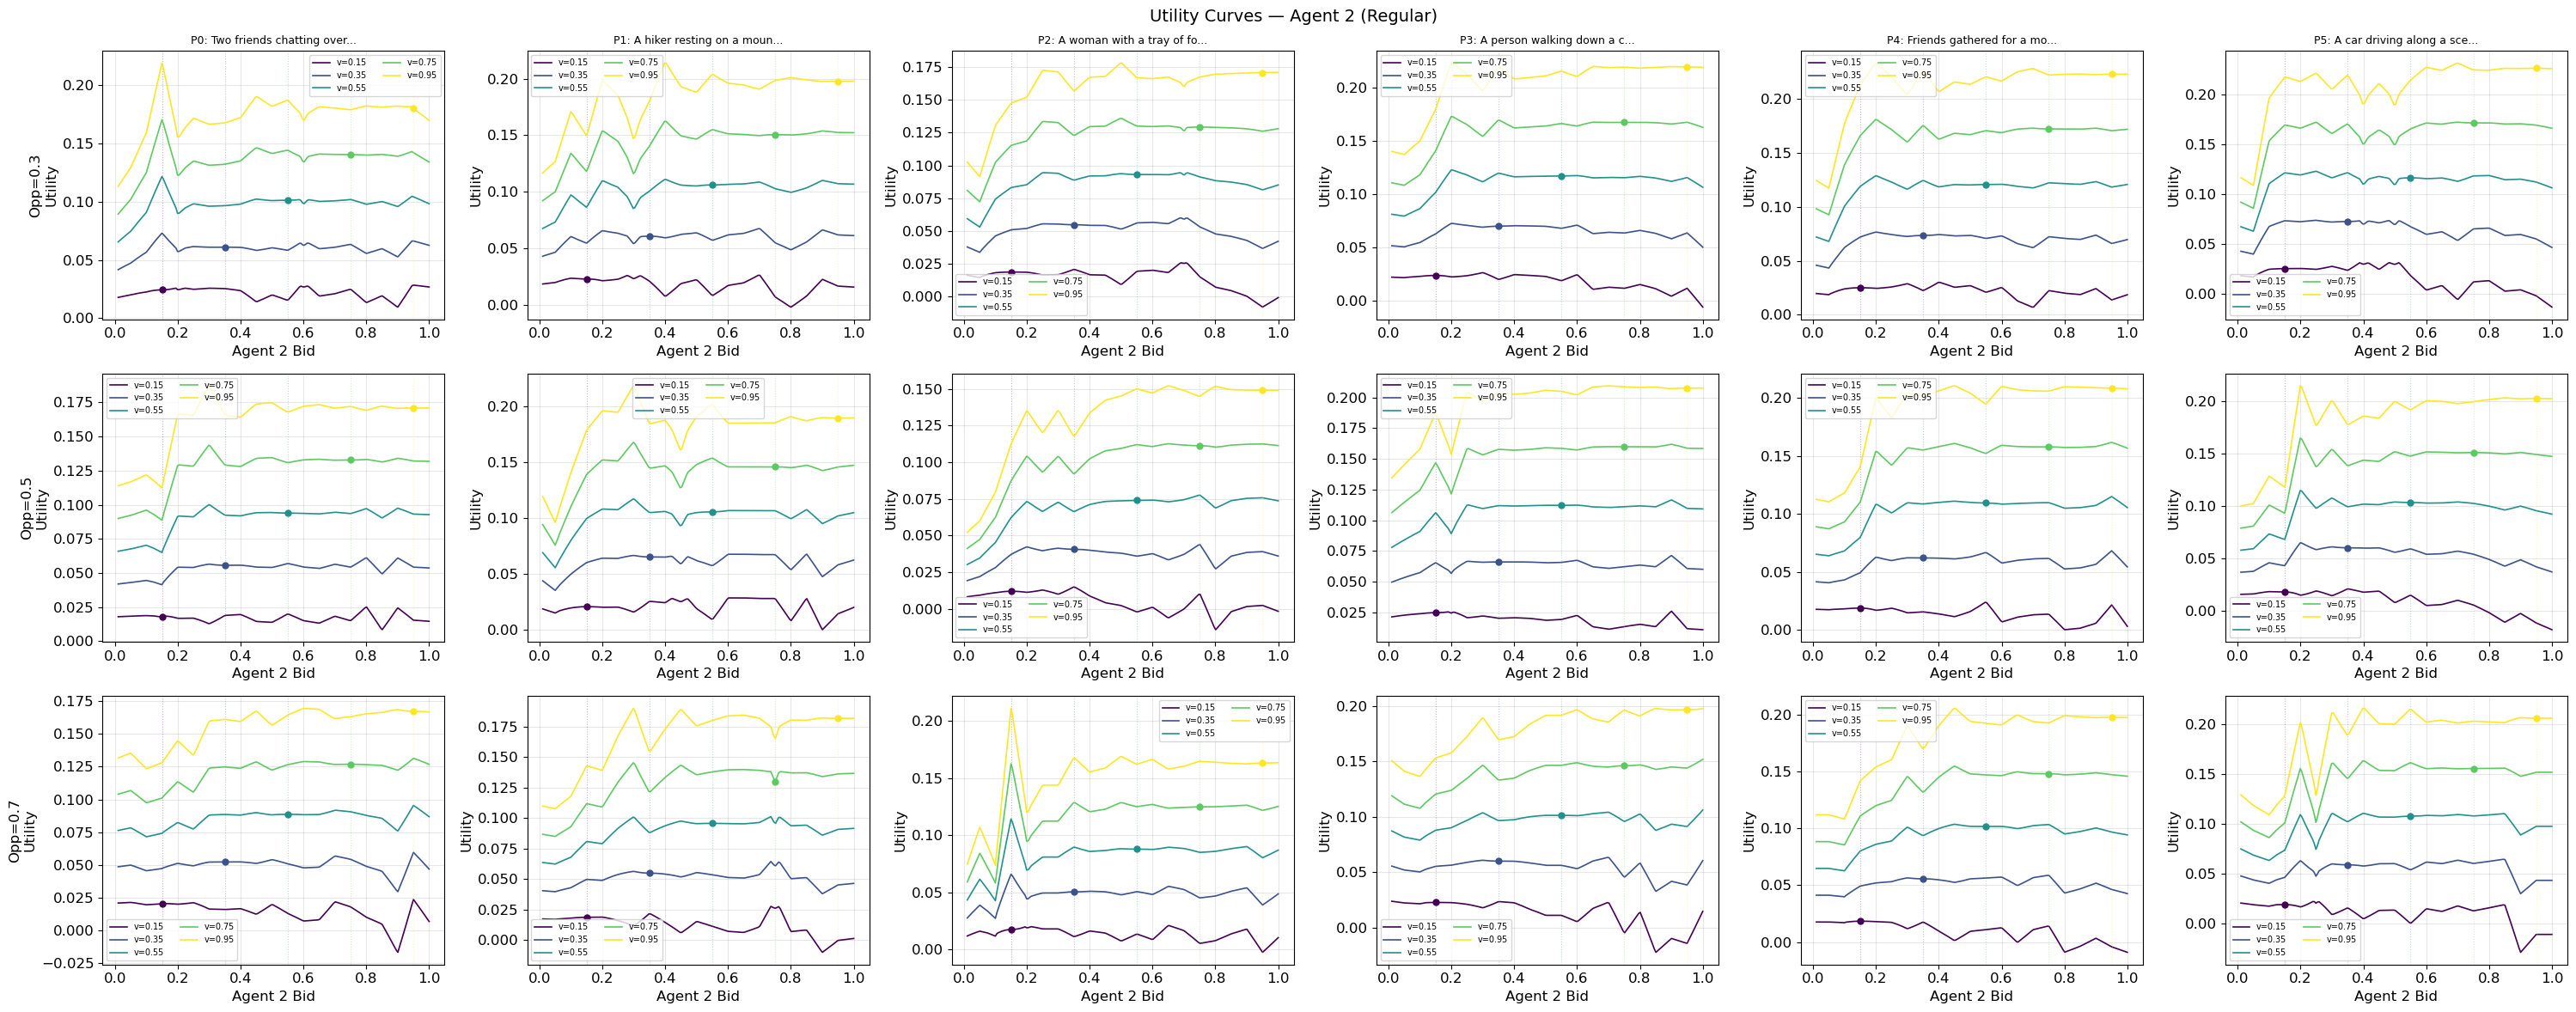

In [15]:
if HAS_REGULAR and curves_a1_reg:
    fig = plot_utility_curves(curves_a1_reg, 'Agent 1', 'Regular', prompts_regular)
    fig.savefig(os.path.join(RESULTS_DIR, 'utility_curves_a1_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()

    fig = plot_utility_curves(curves_a2_reg, 'Agent 2', 'Regular', prompts_regular)
    fig.savefig(os.path.join(RESULTS_DIR, 'utility_curves_a2_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping regular utility plots (no data)')

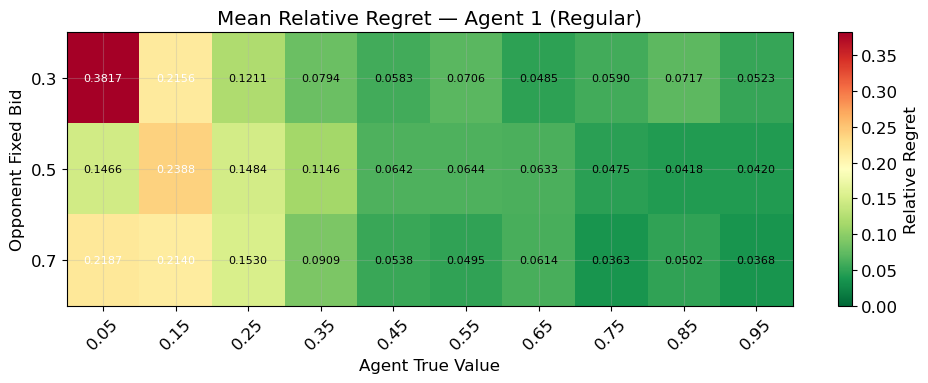

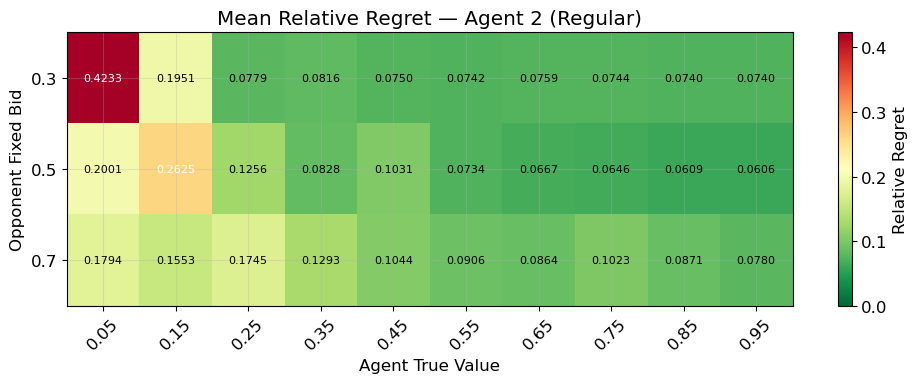

In [16]:
if HAS_REGULAR and len(regret_a1_reg) > 0:
    fig = plot_regret_heatmap(regret_a1_reg, 'Agent 1', 'Regular')
    fig.savefig(os.path.join(RESULTS_DIR, 'regret_heatmap_a1_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()

    fig = plot_regret_heatmap(regret_a2_reg, 'Agent 2', 'Regular')
    fig.savefig(os.path.join(RESULTS_DIR, 'regret_heatmap_a2_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping regular regret heatmaps (no data)')

## 7. Generate All Plots — Competitive

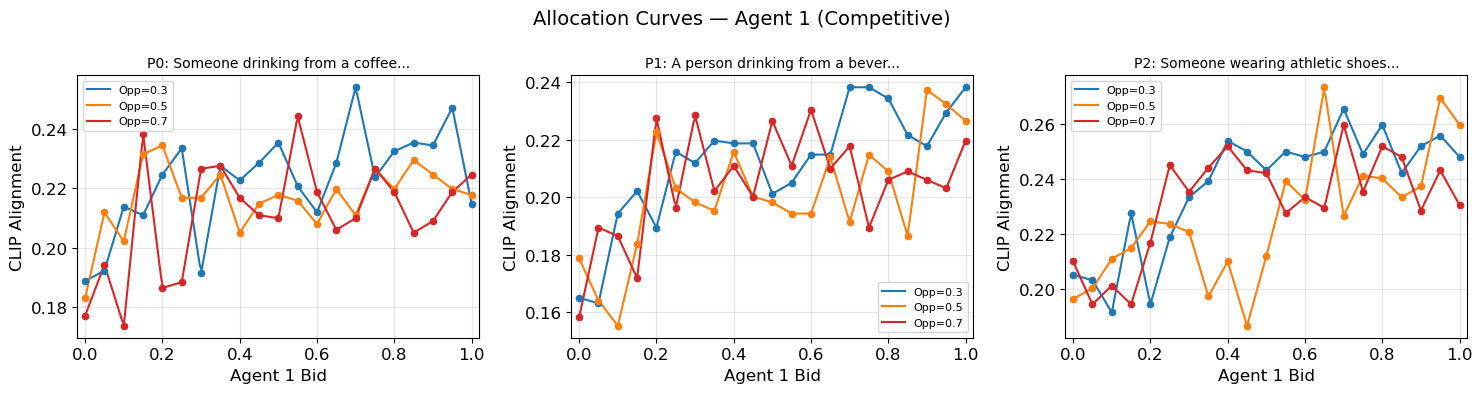

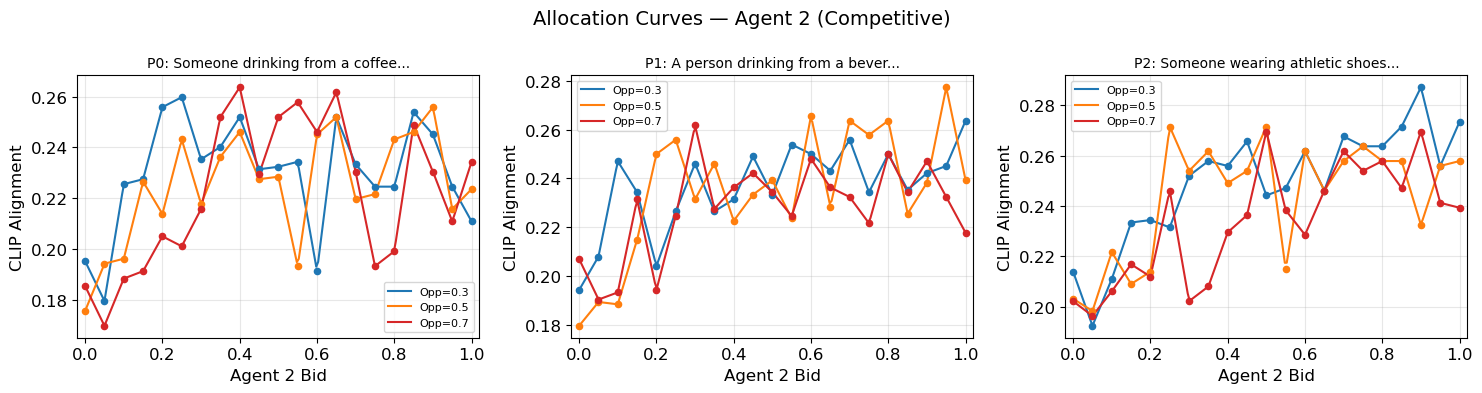

In [17]:
if HAS_COMPETITIVE and curves_a1_comp:
    with open('../prompts/truthfulness_competitive.json') as f:
        prompts_competitive = json.load(f)

    fig = plot_allocation_curves(curves_a1_comp, 'Agent 1', 'Competitive', prompts_competitive)
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_curves_a1_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()

    fig = plot_allocation_curves(curves_a2_comp, 'Agent 2', 'Competitive', prompts_competitive)
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_curves_a2_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping competitive allocation plots (no data yet)')

/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


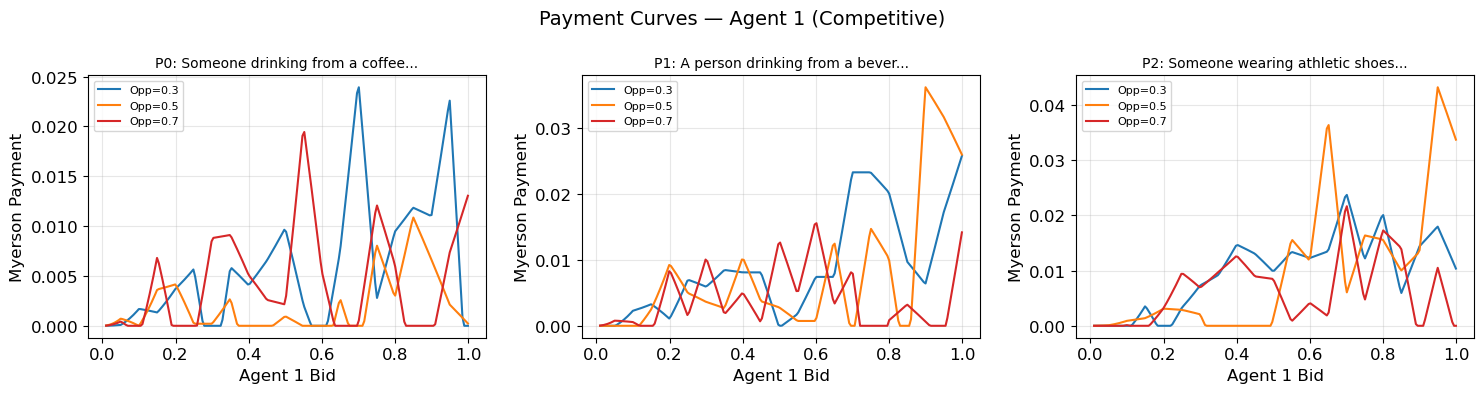

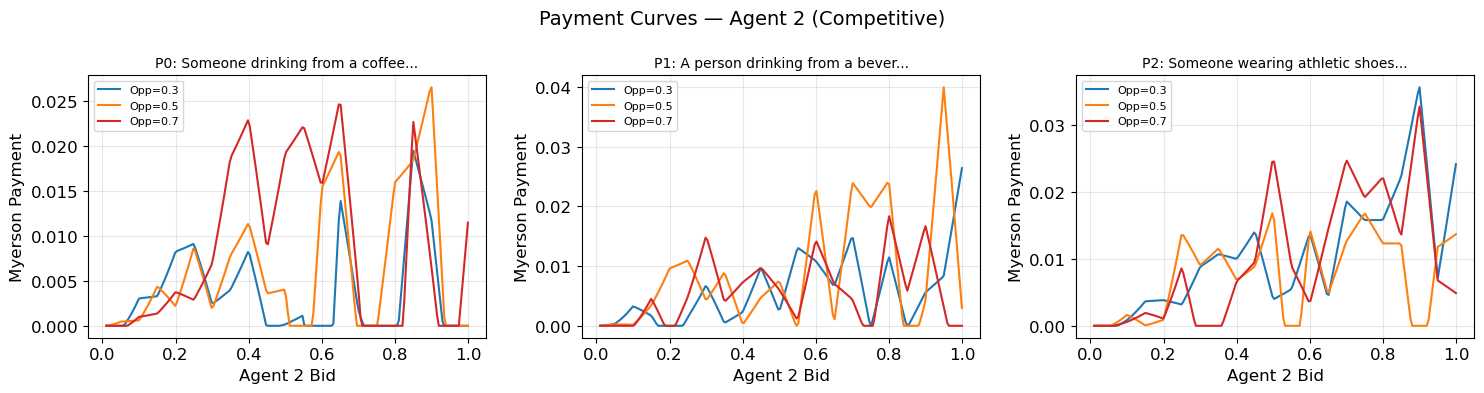

In [18]:
if HAS_COMPETITIVE and curves_a1_comp:
    fig = plot_payment_curves(curves_a1_comp, 'Agent 1', 'Competitive', prompts_competitive)
    fig.savefig(os.path.join(RESULTS_DIR, 'payment_curves_a1_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()

    fig = plot_payment_curves(curves_a2_comp, 'Agent 2', 'Competitive', prompts_competitive)
    fig.savefig(os.path.join(RESULTS_DIR, 'payment_curves_a2_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping competitive payment plots (no data yet)')

/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


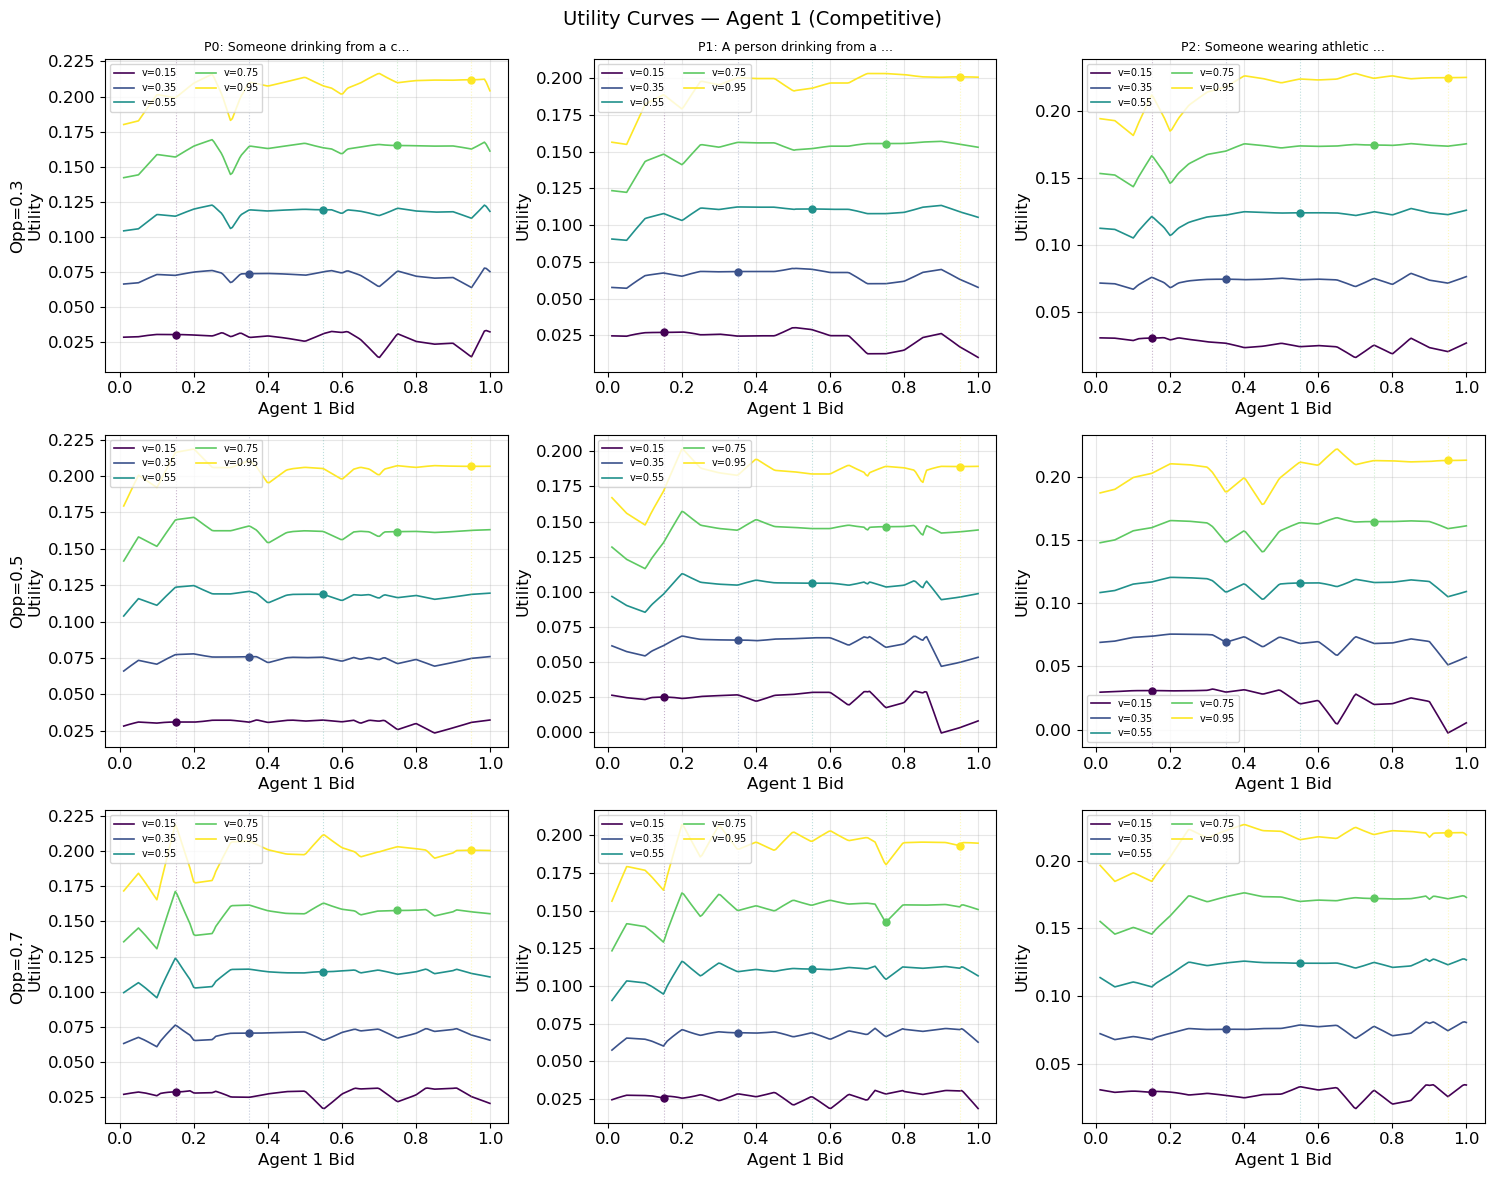

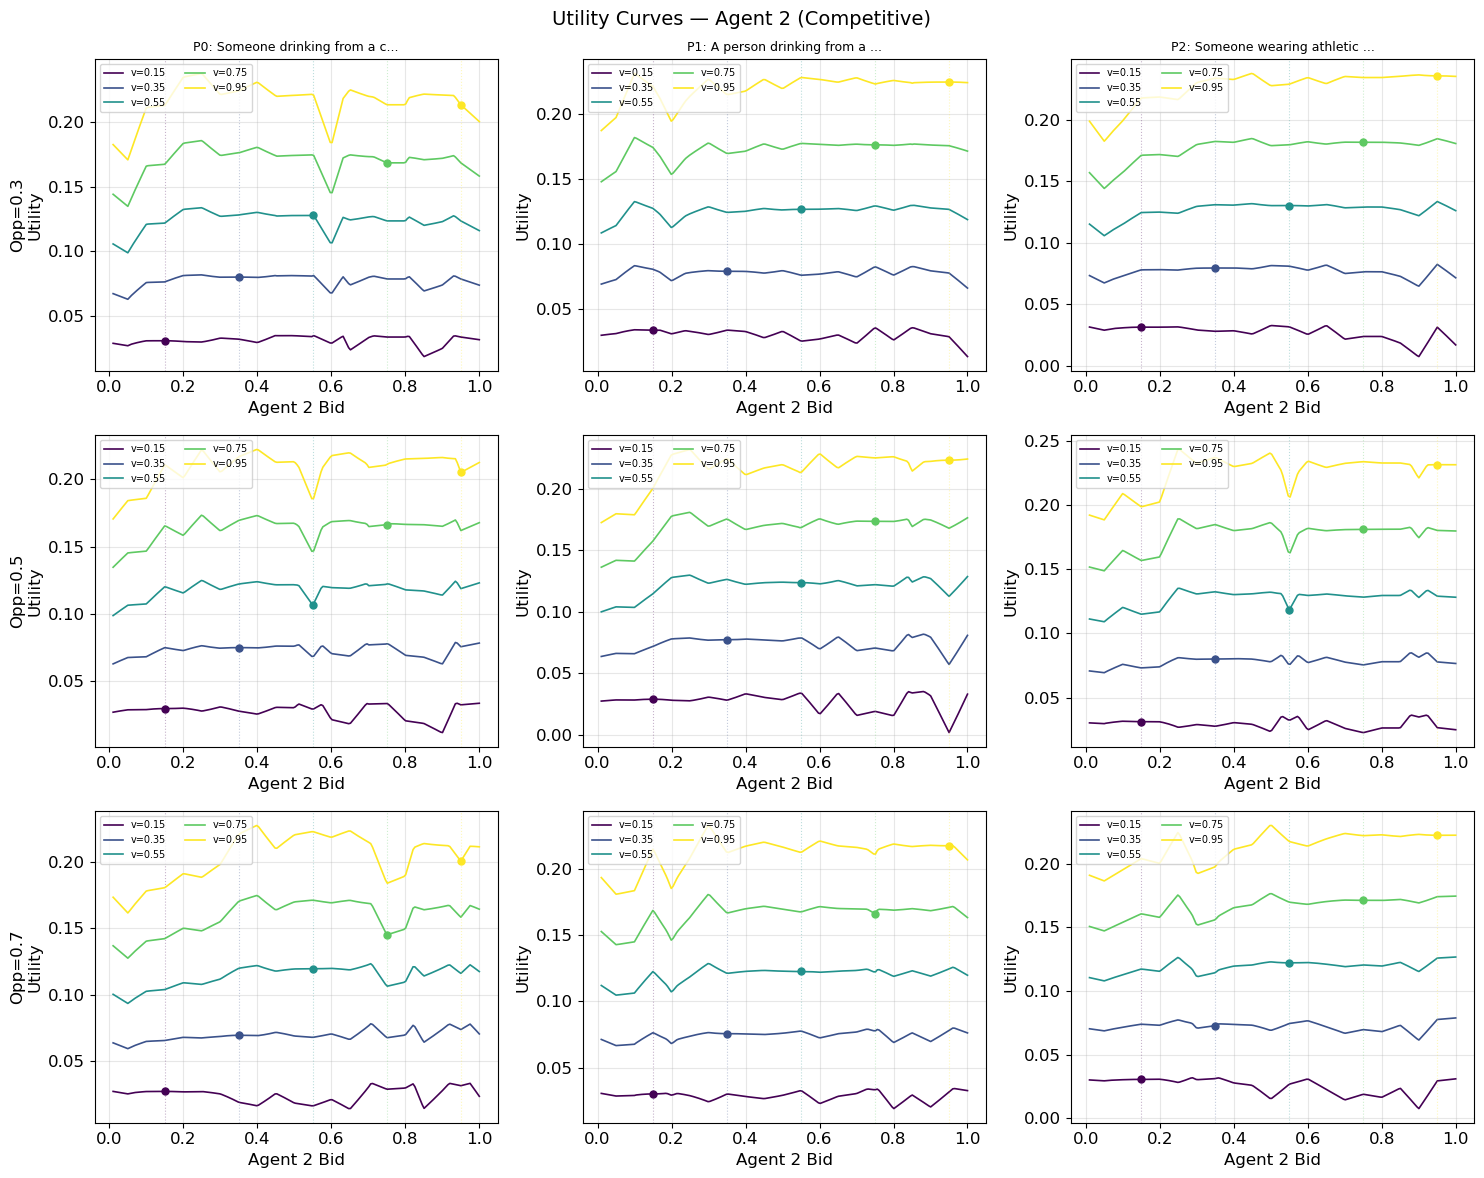

In [19]:
if HAS_COMPETITIVE and curves_a1_comp:
    fig = plot_utility_curves(curves_a1_comp, 'Agent 1', 'Competitive', prompts_competitive)
    fig.savefig(os.path.join(RESULTS_DIR, 'utility_curves_a1_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()

    fig = plot_utility_curves(curves_a2_comp, 'Agent 2', 'Competitive', prompts_competitive)
    fig.savefig(os.path.join(RESULTS_DIR, 'utility_curves_a2_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping competitive utility plots (no data yet)')

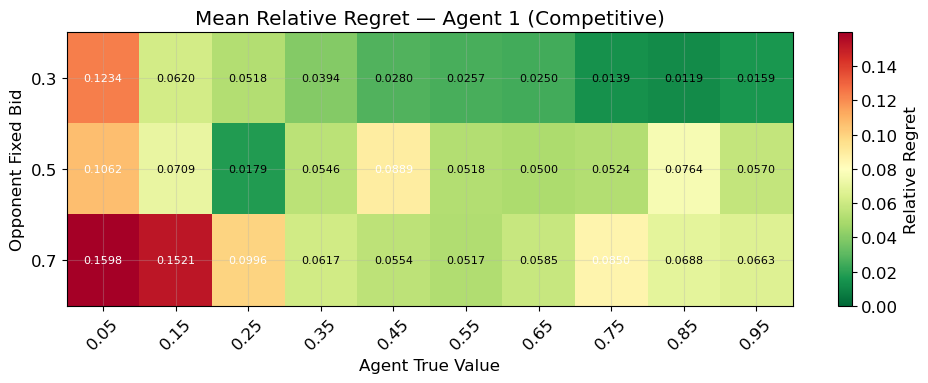

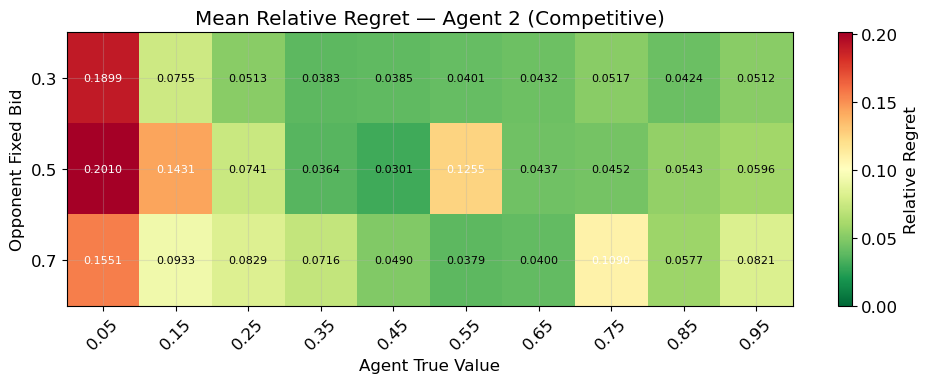

In [20]:
if HAS_COMPETITIVE and len(regret_a1_comp) > 0:
    fig = plot_regret_heatmap(regret_a1_comp, 'Agent 1', 'Competitive')
    fig.savefig(os.path.join(RESULTS_DIR, 'regret_heatmap_a1_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()

    fig = plot_regret_heatmap(regret_a2_comp, 'Agent 2', 'Competitive')
    fig.savefig(os.path.join(RESULTS_DIR, 'regret_heatmap_a2_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping competitive regret heatmaps (no data yet)')

## 8. Aggregate Plots

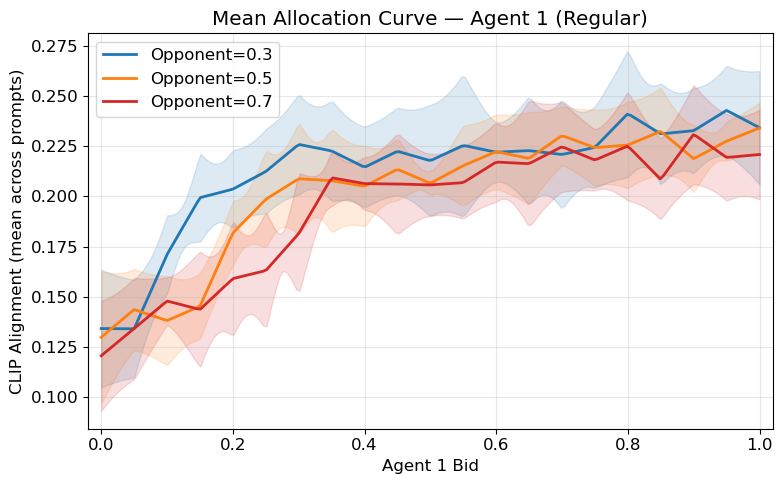

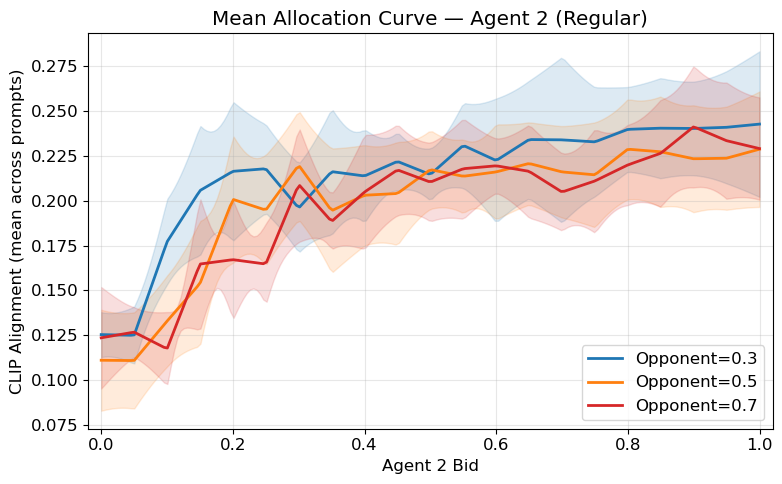

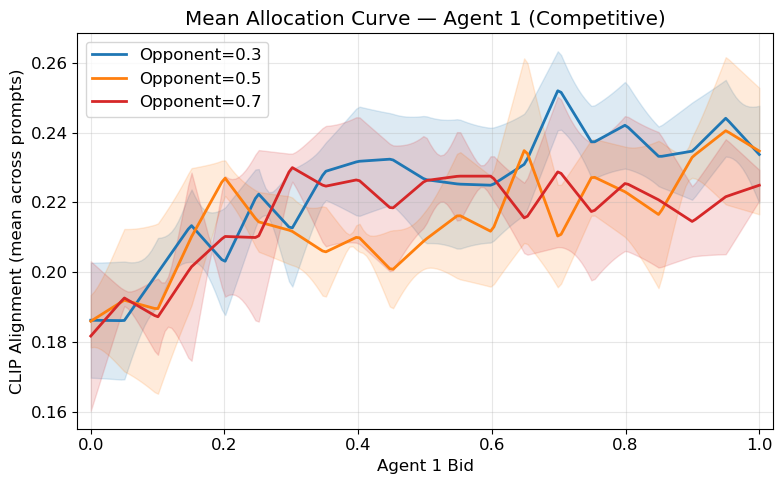

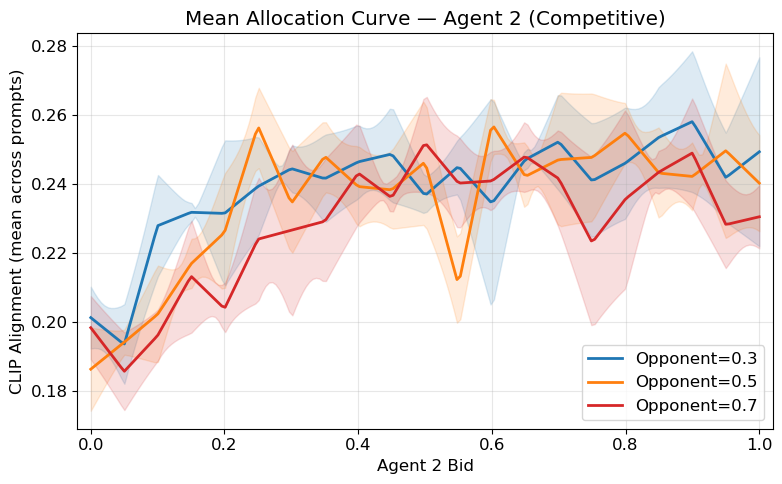

In [21]:
def plot_mean_allocation_curves(curves, agent_name, dataset_name):
    """Plot mean allocation curves (averaged across prompts) with error bars."""
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = {0.3: 'tab:blue', 0.5: 'tab:orange', 0.7: 'tab:red'}
    
    for fv in FIXED_VALUES:
        # Collect all prompt curves for this fixed value
        prompt_keys = [k for k in curves if k[1] == fv]
        if not prompt_keys:
            continue
        
        fine_bids = np.linspace(0, 1, 200)
        all_allocs = np.array([curves[k]['interp_fn'](fine_bids) for k in prompt_keys])
        mean_alloc = all_allocs.mean(axis=0)
        std_alloc = all_allocs.std(axis=0)
        
        ax.plot(fine_bids, mean_alloc, color=colors[fv], label=f'Opponent={fv}', linewidth=2)
        ax.fill_between(fine_bids, mean_alloc - std_alloc, mean_alloc + std_alloc, 
                        color=colors[fv], alpha=0.15)
    
    ax.set_xlabel(f'{agent_name} Bid')
    ax.set_ylabel('CLIP Alignment (mean across prompts)')
    ax.set_title(f'Mean Allocation Curve — {agent_name} ({dataset_name})')
    ax.legend()
    ax.set_xlim(-0.02, 1.02)
    plt.tight_layout()
    return fig

if curves_a1_reg:
    fig = plot_mean_allocation_curves(curves_a1_reg, 'Agent 1', 'Regular')
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_curves_mean_a1_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()
    fig = plot_mean_allocation_curves(curves_a2_reg, 'Agent 2', 'Regular')
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_curves_mean_a2_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()

if curves_a1_comp:
    fig = plot_mean_allocation_curves(curves_a1_comp, 'Agent 1', 'Competitive')
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_curves_mean_a1_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()
    fig = plot_mean_allocation_curves(curves_a2_comp, 'Agent 2', 'Competitive')
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_curves_mean_a2_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()

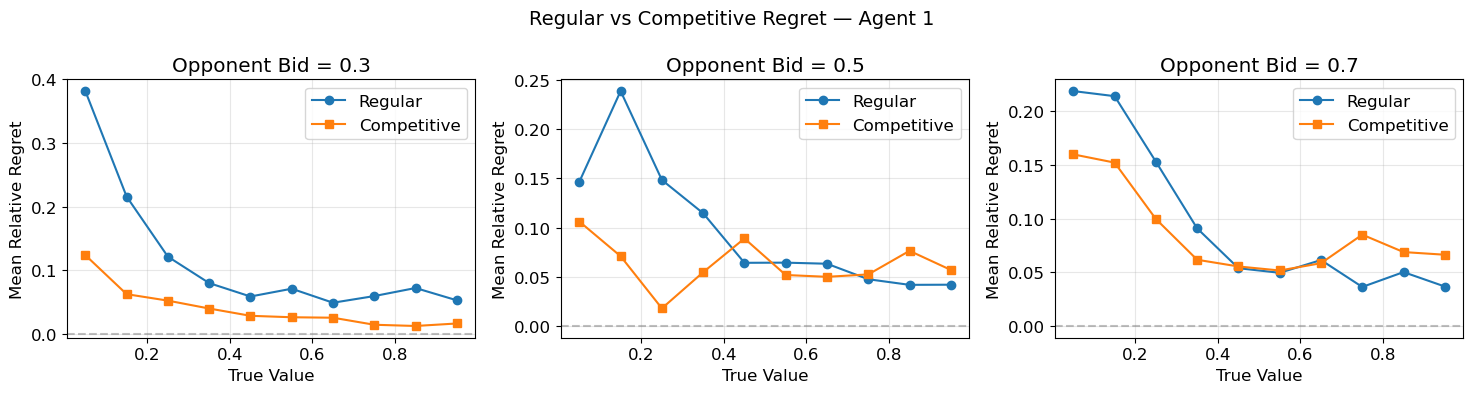

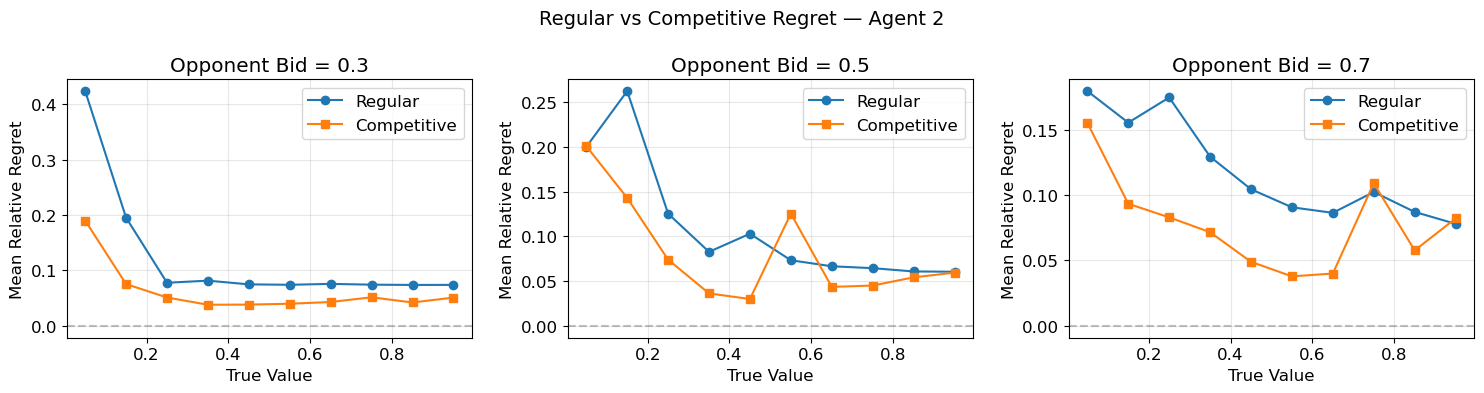

In [22]:
def plot_regular_vs_competitive_regret(reg_regret, comp_regret, agent_name):
    """Compare mean relative regret between regular and competitive settings."""
    fig, axes = plt.subplots(1, len(FIXED_VALUES), figsize=(5*len(FIXED_VALUES), 4), squeeze=False)
    
    for col, fv in enumerate(FIXED_VALUES):
        ax = axes[0, col]
        
        reg_sub = reg_regret[np.isclose(reg_regret['fixed_val'], fv)]
        comp_sub = comp_regret[np.isclose(comp_regret['fixed_val'], fv)]
        
        reg_mean = reg_sub.groupby('true_value')['relative_regret'].mean()
        comp_mean = comp_sub.groupby('true_value')['relative_regret'].mean()
        
        ax.plot(reg_mean.index, reg_mean.values, 'o-', label='Regular', linewidth=1.5)
        ax.plot(comp_mean.index, comp_mean.values, 's-', label='Competitive', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('True Value')
        ax.set_ylabel('Mean Relative Regret')
        ax.set_title(f'Opponent Bid = {fv}')
        ax.legend()
    
    fig.suptitle(f'Regular vs Competitive Regret — {agent_name}', fontsize=14)
    plt.tight_layout()
    return fig

if len(regret_a1_reg) > 0 and len(regret_a1_comp) > 0:
    fig = plot_regular_vs_competitive_regret(regret_a1_reg, regret_a1_comp, 'Agent 1')
    fig.savefig(os.path.join(RESULTS_DIR, 'regular_vs_competitive_a1.png'), dpi=150, bbox_inches='tight')
    plt.show()
    fig = plot_regular_vs_competitive_regret(regret_a2_reg, regret_a2_comp, 'Agent 2')
    fig.savefig(os.path.join(RESULTS_DIR, 'regular_vs_competitive_a2.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping regular vs competitive comparison (need both datasets)')

## 9. Surplus Decomposition & Monotonicity Verification

/tmp/ipykernel_47817/3080744043.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(x_vals, z_vals)


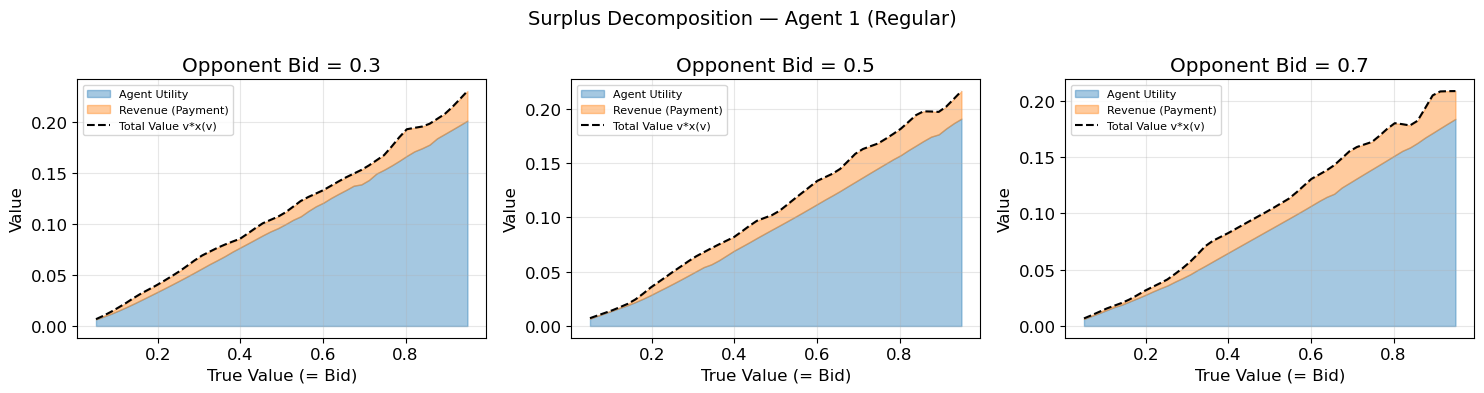

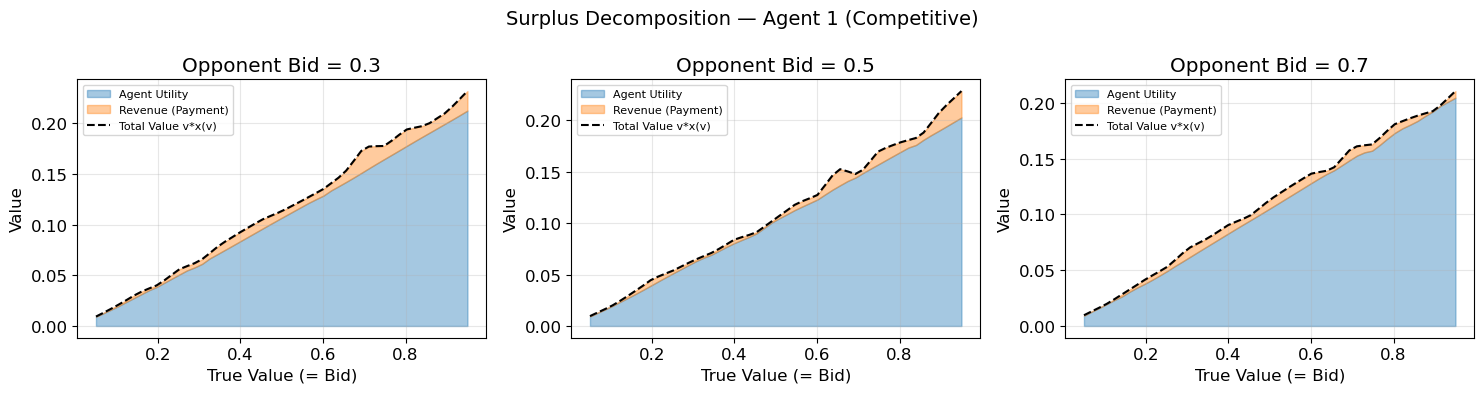

In [23]:
def plot_surplus_decomposition(curves, agent_name, dataset_name):
    """Plot surplus decomposition: agent utility + mechanism revenue = total value."""
    fig, axes = plt.subplots(1, len(FIXED_VALUES), figsize=(5*len(FIXED_VALUES), 4), squeeze=False)
    
    for col, fv in enumerate(FIXED_VALUES):
        ax = axes[0, col]
        prompt_keys = [k for k in curves if k[1] == fv]
        if not prompt_keys:
            continue
        
        true_values = np.linspace(0.05, 0.95, 50)
        all_utilities = []
        all_revenues = []
        all_total_values = []
        
        for key in prompt_keys:
            interp_fn = curves[key]['interp_fn']
            utils, revs, totals = [], [], []
            for v in true_values:
                x_v = float(interp_fn(v))
                total_val = v * x_v
                payment = compute_myerson_payment(interp_fn, v)
                utils.append(total_val - payment)
                revs.append(payment)
                totals.append(total_val)
            all_utilities.append(utils)
            all_revenues.append(revs)
            all_total_values.append(totals)
        
        mean_util = np.mean(all_utilities, axis=0)
        mean_rev = np.mean(all_revenues, axis=0)
        mean_total = np.mean(all_total_values, axis=0)
        
        ax.fill_between(true_values, 0, mean_util, alpha=0.4, label='Agent Utility', color='tab:blue')
        ax.fill_between(true_values, mean_util, mean_util + mean_rev, alpha=0.4, label='Revenue (Payment)', color='tab:orange')
        ax.plot(true_values, mean_total, 'k--', linewidth=1.5, label='Total Value v*x(v)')
        ax.set_xlabel('True Value (= Bid)')
        ax.set_ylabel('Value')
        ax.set_title(f'Opponent Bid = {fv}')
        ax.legend(fontsize=8)
    
    fig.suptitle(f'Surplus Decomposition — {agent_name} ({dataset_name})', fontsize=14)
    plt.tight_layout()
    return fig

if curves_a1_reg:
    fig = plot_surplus_decomposition(curves_a1_reg, 'Agent 1', 'Regular')
    fig.savefig(os.path.join(RESULTS_DIR, 'surplus_decomposition_a1_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()

if curves_a1_comp:
    fig = plot_surplus_decomposition(curves_a1_comp, 'Agent 1', 'Competitive')
    fig.savefig(os.path.join(RESULTS_DIR, 'surplus_decomposition_a1_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()

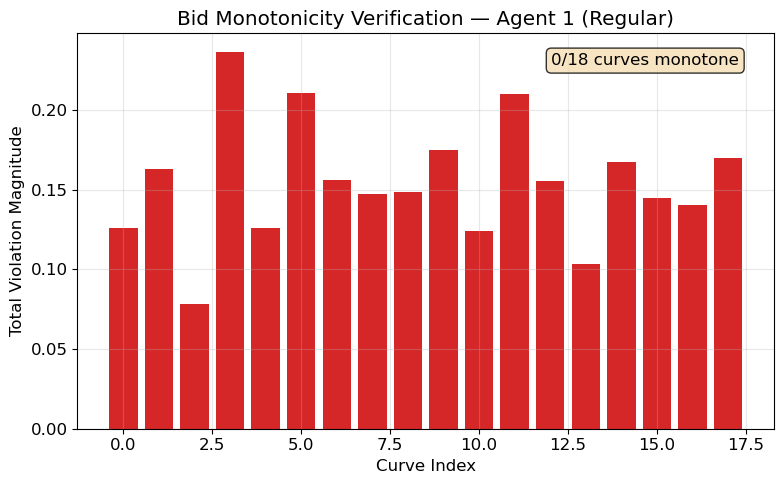

 prompt_idx  fixed_val  n_violations  violation_magnitude  n_points
          0        0.3             6             0.125732        21
          0        0.5             6             0.163086        21
          0        0.7             2             0.078125        21
          1        0.3             7             0.236328        21
          1        0.5             5             0.125977        21
          1        0.7             5             0.210938        21
          2        0.3             6             0.156250        21
          2        0.5             6             0.147461        21
          2        0.7             6             0.148438        21
          3        0.3             5             0.174805        21
          3        0.5             5             0.124023        21
          3        0.7             7             0.209961        21
          4        0.3             4             0.155273        21
          4        0.5             3            

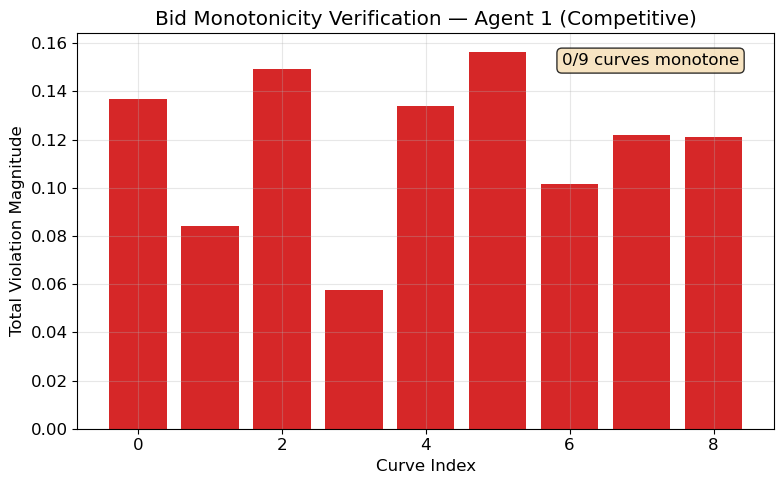

 prompt_idx  fixed_val  n_violations  violation_magnitude  n_points
          0        0.3             4             0.136719        21
          0        0.5             2             0.083984        21
          0        0.7             6             0.149414        21
          1        0.3             3             0.057617        21
          1        0.5             5             0.133789        21
          1        0.7             7             0.156250        21
          2        0.3             4             0.101562        21
          2        0.5             3             0.122070        21
          2        0.7             5             0.121094        21


In [24]:
def verify_monotonicity(curves, agent_name, dataset_name):
    """Verify that allocation curves are monotonically non-decreasing."""
    if not curves:
        print(f'No curves for {agent_name} ({dataset_name})')
        return None, pd.DataFrame()
    
    fig, ax = plt.subplots(figsize=(8, 5))
    violations = []
    for key, curve_data in curves.items():
        pidx, fv = key
        bids = curve_data['bids']
        allocs = curve_data['allocations']
        diffs = np.diff(allocs)
        n_violations = np.sum(diffs < -0.01)
        violation_magnitude = -np.minimum(diffs, 0).sum()
        violations.append({'prompt_idx': pidx, 'fixed_val': fv, 'n_violations': n_violations,
                          'violation_magnitude': violation_magnitude, 'n_points': len(bids)})
    
    vdf = pd.DataFrame(violations)
    ax.bar(range(len(vdf)), vdf['violation_magnitude'],
           color=['tab:green' if v == 0 else 'tab:red' for v in vdf['n_violations']])
    ax.set_xlabel('Curve Index')
    ax.set_ylabel('Total Violation Magnitude')
    ax.set_title(f'Bid Monotonicity Verification — {agent_name} ({dataset_name})')
    n_monotone = (vdf['n_violations'] == 0).sum()
    ax.text(0.95, 0.95, f'{n_monotone}/{len(vdf)} curves monotone',
            transform=ax.transAxes, ha='right', va='top', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    plt.tight_layout()
    return fig, vdf

if curves_a1_reg:
    fig, vdf_reg = verify_monotonicity(curves_a1_reg, 'Agent 1', 'Regular')
    if fig: fig.savefig(os.path.join(RESULTS_DIR, 'bid_monotonicity_a1_regular.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(vdf_reg.to_string(index=False))

if curves_a1_comp:
    fig, vdf_comp = verify_monotonicity(curves_a1_comp, 'Agent 1', 'Competitive')
    if fig: fig.savefig(os.path.join(RESULTS_DIR, 'bid_monotonicity_a1_competitive.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(vdf_comp.to_string(index=False))

## 10. Export Data

In [25]:
# Combine available regret data and save
dfs_to_concat = []
if len(regret_a1_reg) > 0:
    regret_a1_reg['agent'] = 'Agent 1'; regret_a1_reg['dataset'] = 'Regular'
    dfs_to_concat.append(regret_a1_reg)
if len(regret_a2_reg) > 0:
    regret_a2_reg['agent'] = 'Agent 2'; regret_a2_reg['dataset'] = 'Regular'
    dfs_to_concat.append(regret_a2_reg)
if len(regret_a1_comp) > 0:
    regret_a1_comp['agent'] = 'Agent 1'; regret_a1_comp['dataset'] = 'Competitive'
    dfs_to_concat.append(regret_a1_comp)
if len(regret_a2_comp) > 0:
    regret_a2_comp['agent'] = 'Agent 2'; regret_a2_comp['dataset'] = 'Competitive'
    dfs_to_concat.append(regret_a2_comp)

if dfs_to_concat:
    all_regret = pd.concat(dfs_to_concat, ignore_index=True)
    all_regret.to_csv(os.path.join(RESULTS_DIR, 'data.csv'), index=False)
    print(f'Saved {len(all_regret)} rows to {RESULTS_DIR}/data.csv')

    summary = all_regret.groupby(['dataset', 'agent']).agg(
        mean_regret=('relative_regret', 'mean'),
        max_regret=('relative_regret', 'max'),
        median_regret=('relative_regret', 'median'),
        std_regret=('relative_regret', 'std'),
    ).reset_index()
    print('\nSummary:')
    print(summary.to_string(index=False))
else:
    print('No regret data to export yet')

Saved 540 rows to ../results/truthfulness/data.csv

Summary:
    dataset   agent  mean_regret  max_regret  median_regret  std_regret
Competitive Agent 1     0.062731    0.233533       0.048445    0.050222
Competitive Agent 2     0.073791    0.288043       0.050610    0.056948
    Regular Agent 1     0.103142    0.862528       0.061442    0.121518
    Regular Agent 2     0.117106    0.806765       0.065359    0.132077
